# E-Commerce Customer & Sales Analysis Using SQL

## Project Overview

This project analyses transaction-level e-commerce data using **SQLite SQL** to understand revenue performance, customer behaviour, product performance, repeat purchasing and customer recency.

Python is used only to load the Excel dataset into SQLite, display query results and create one supporting trend chart. The core analysis is performed in SQL.

### Business Questions

1. What are the key sales KPIs?
2. Which countries generate the most revenue?
3. Who are the highest-value and most frequent customers?
4. How does revenue change over time?
5. Which products generate the most revenue and unit volume?
6. What proportion of customers are repeat buyers?
7. Which customers are active, at risk or inactive?
8. Which valuable customers should be prioritised for retention?

### SQL Skills Demonstrated

- `SELECT`, `WHERE`, `GROUP BY`, `ORDER BY`, `LIMIT`
- `COUNT`, `SUM`, `AVG`, `ROUND`
- `CASE WHEN`
- `HAVING`
- Common Table Expressions (CTEs)
- Window functions: `RANK()` and `LAG()`
- `INNER JOIN`
- Date analysis with SQLite `strftime()` and `julianday()`


## 1. Setup and Load the Dataset

The source file is the UCI Online Retail dataset. In Google Colab, upload `Online Retail.xlsx` to the session before running the notebook.


In [24]:
import pandas as pd
import sqlite3

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [25]:
file_path = "/content/Online Retail.xlsx"

df = pd.read_excel(file_path)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


The raw dataset contains **541,909 transaction rows and 8 columns**. Each row represents a product line within an invoice, so one invoice can appear across multiple rows.


In [26]:
df.shape

(541909, 8)

In [27]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

## 2. Create the SQLite Database

The Excel data is loaded into a SQLite database table called `transactions`. This allows the rest of the analysis to be performed with SQL.


In [28]:
conn = sqlite3.connect("ecommerce.db")

df.to_sql(
    "transactions",
    conn,
    if_exists="replace",
    index=False
)

print("SQL database created successfully!")

SQL database created successfully!


In [29]:
query = """
SELECT *
FROM transactions
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [30]:
query = """
SELECT COUNT(*) AS total_transactions
FROM transactions;
"""

pd.read_sql_query(query, conn)

,total_transactions
0,541909


## 3. Data Quality Checks

Before analysis, the raw transactions are checked for missing customer IDs, cancelled invoices, non-positive quantities and non-positive prices.


### Missing Customer IDs


In [31]:
query = """
SELECT COUNT(*) AS missing_customer_ids
FROM transactions
WHERE CustomerID IS NULL;
"""

pd.read_sql_query(query, conn)

,missing_customer_ids
0,135080


### Cancelled Invoices


In [32]:
query = """
SELECT COUNT(*) AS cancelled_transactions
FROM transactions
WHERE InvoiceNo LIKE 'C%';
"""

pd.read_sql_query(query, conn)

,cancelled_transactions
0,9288


### Non-Positive Quantities


In [33]:
query = """
SELECT COUNT(*) AS non_positive_quantity
FROM transactions
WHERE Quantity <= 0;
"""

pd.read_sql_query(query, conn)

,non_positive_quantity
0,10624


### Non-Positive Prices


In [34]:
query = """
SELECT COUNT(*) AS non_positive_price
FROM transactions
WHERE UnitPrice <= 0;
"""

pd.read_sql_query(query, conn)

,non_positive_price
0,2517


### Data Quality Summary

The raw data contains:

- **135,080** rows with missing customer IDs
- **9,288** cancelled transaction rows
- **10,624** rows with non-positive quantities
- **2,517** rows with non-positive unit prices

These counts overlap, so they should not be added together. A single row can fail more than one quality check.


## 4. Build an Analysis-Ready Table

A separate `clean_transactions` table is created so the raw `transactions` table remains unchanged.

Rows are retained only when they have a known customer, are not cancellation invoices, and have positive quantity and price. A new `Revenue` field is calculated as:

**Revenue = Quantity × UnitPrice**


In [35]:
query = """
CREATE TABLE clean_transactions AS

SELECT
    InvoiceNo,
    StockCode,
    Description,
    Quantity,
    InvoiceDate,
    UnitPrice,
    CustomerID,
    Country,
    Quantity * UnitPrice AS Revenue

FROM transactions

WHERE CustomerID IS NOT NULL
  AND InvoiceNo NOT LIKE 'C%'
  AND Quantity > 0
  AND UnitPrice > 0;
"""

conn.execute("DROP TABLE IF EXISTS clean_transactions;")
conn.execute(query)
conn.commit()

print("Clean transactions table created!")

Clean transactions table created!


In [36]:
query = """
SELECT COUNT(*) AS clean_transactions
FROM clean_transactions;
"""

pd.read_sql_query(query, conn)

,clean_transactions
0,397884


In [37]:
query = """
SELECT *
FROM clean_transactions
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


The cleaned table contains **397,884 transaction rows**, meaning 144,025 raw rows were excluded by at least one cleaning rule.


## 5. Core Business KPIs


In [38]:
query = """
SELECT
    ROUND(SUM(Revenue), 2) AS total_revenue,
    COUNT(DISTINCT InvoiceNo) AS total_orders,
    COUNT(DISTINCT CustomerID) AS total_customers,
    SUM(Quantity) AS total_units_sold,
    ROUND(
        SUM(Revenue) / COUNT(DISTINCT InvoiceNo),
        2
    ) AS average_order_value
FROM clean_transactions;
"""

pd.read_sql_query(query, conn)

,total_revenue,total_orders,total_customers,total_units_sold,average_order_value
0,8911407.9,18532,4338,5167812,480.87


### KPI Summary

| KPI | Result |
|---|---:|
| Total Revenue | **£8,911,407.90** |
| Total Orders | **18,532** |
| Total Customers | **4,338** |
| Total Units Sold | **5,167,812** |
| Average Order Value | **£480.87** |

The distinction between transaction rows and orders is important: one invoice can contain many product lines, so unique invoice numbers are counted to measure orders.


## 6. Country Performance

Revenue, order count, customer count and average order value are compared by country.


In [40]:
query = """
SELECT
    Country,
    ROUND(SUM(Revenue), 2) AS total_revenue,
    COUNT(DISTINCT InvoiceNo) AS total_orders,
    COUNT(DISTINCT CustomerID) AS total_customers,
    ROUND(
        SUM(Revenue) / COUNT(DISTINCT InvoiceNo),
        2
    ) AS average_order_value
FROM clean_transactions
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,Country,total_revenue,total_orders,total_customers,average_order_value
0,United Kingdom,7308391.55,16646,3920,439.05
1,Netherlands,285446.34,94,9,3036.66
2,EIRE,265545.90,260,3,1021.33
3,Germany,228867.14,457,94,500.80
4,France,209024.05,389,87,537.34
5,Australia,138521.31,57,9,2430.20
6,Spain,61577.11,90,30,684.19
7,Switzerland,56443.95,51,21,1106.74
8,Belgium,41196.34,98,25,420.37
9,Sweden,38378.33,36,8,1066.06


### Country Insight

The **United Kingdom** generated approximately **£7.31 million**, or about **82% of cleaned revenue**, making it the retailer's dominant market.

However, revenue profiles differ substantially across countries. The Netherlands and Australia have relatively few customers but very high average order values, while Germany and France have broader customer bases and more moderate order values.


## 7. Customer Value and Purchase Frequency

The analysis compares customers by total spending and order frequency to show that a high-value customer is not necessarily the most frequent customer.


### Highest-Value Customers


In [41]:
query = """
SELECT
    CustomerID,
    Country,
    ROUND(SUM(Revenue), 2) AS total_revenue,
    COUNT(DISTINCT InvoiceNo) AS total_orders,
    ROUND(
        SUM(Revenue) / COUNT(DISTINCT InvoiceNo),
        2
    ) AS average_order_value
FROM clean_transactions
GROUP BY CustomerID, Country
ORDER BY total_revenue DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,CustomerID,Country,total_revenue,total_orders,average_order_value
0,14646.0,Netherlands,280206.02,73,3838.44
1,18102.0,United Kingdom,259657.30,60,4327.62
2,17450.0,United Kingdom,194550.79,46,4229.36
3,16446.0,United Kingdom,168472.50,2,84236.25
4,14911.0,EIRE,143825.06,201,715.55
5,12415.0,Australia,124914.53,21,5948.31
6,14156.0,EIRE,117379.63,55,2134.18
7,17511.0,United Kingdom,91062.38,31,2937.50
8,16029.0,United Kingdom,81024.84,63,1286.11
9,12346.0,United Kingdom,77183.60,1,77183.60


### Most Frequent Customers


In [42]:
query = """
SELECT
    CustomerID,
    Country,
    COUNT(DISTINCT InvoiceNo) AS total_orders,
    ROUND(SUM(Revenue), 2) AS total_revenue
FROM clean_transactions
GROUP BY CustomerID, Country
ORDER BY total_orders DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,CustomerID,Country,total_orders,total_revenue
0,12748.0,United Kingdom,209,33719.73
1,14911.0,EIRE,201,143825.06
2,17841.0,United Kingdom,124,40991.57
3,13089.0,United Kingdom,97,58825.83
4,14606.0,United Kingdom,93,12156.65
5,15311.0,United Kingdom,91,60767.90
6,12971.0,United Kingdom,86,11189.91
7,14646.0,Netherlands,73,280206.02
8,16029.0,United Kingdom,63,81024.84
9,13408.0,United Kingdom,62,28117.04


### Customer Insight

Customer `16446` generated approximately **£168,472.50 from only 2 orders**, while customer `14911` generated approximately **£143,825.06 from 201 orders**.

This illustrates two different forms of customer value: **large-order customers** and **high-frequency customers**.


## 8. Revenue Trend Over Time

The dataset covers **1 December 2010 to 9 December 2011**. Because December 2011 is incomplete, it is excluded from the full-month trend comparison.


In [44]:
query = """
SELECT
    MIN(InvoiceDate) AS first_transaction,
    MAX(InvoiceDate) AS last_transaction
FROM clean_transactions;
"""

pd.read_sql_query(query, conn)

,first_transaction,last_transaction
0,2010-12-01 08:26:00,2011-12-09 12:50:00


In [48]:
query = """
SELECT
    strftime('%Y-%m', InvoiceDate) AS month,
    ROUND(SUM(Revenue), 2) AS monthly_revenue
FROM clean_transactions
WHERE InvoiceDate < '2011-12-01'
GROUP BY month
ORDER BY month;
"""

monthly_revenue_full = pd.read_sql_query(query, conn)

monthly_revenue_full

,month,monthly_revenue
0,2010-12,572713.89
1,2011-01,569445.04
2,2011-02,447137.35
3,2011-03,595500.76
4,2011-04,469200.36
5,2011-05,678594.56
6,2011-06,661213.69
7,2011-07,600091.01
8,2011-08,645343.90
9,2011-09,952838.38


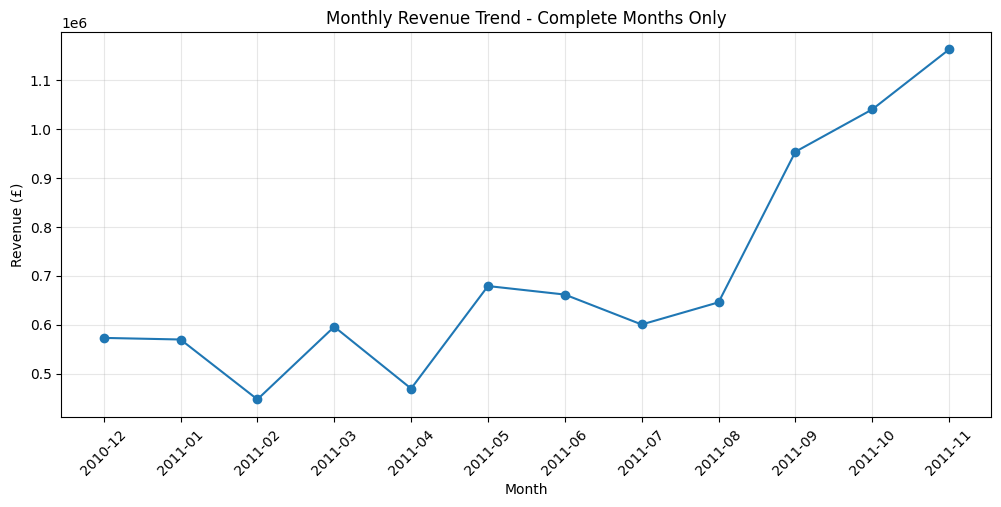

In [49]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue_full["month"],
    monthly_revenue_full["monthly_revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend - Complete Months Only")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

### Trend Insight

Revenue was relatively stable through early and mid-2011 before accelerating strongly from September. **November 2011 was the strongest complete month**, generating approximately **£1.16 million**.

The incomplete December 2011 period is excluded from this comparison to avoid a misleading apparent decline.


### Month-on-Month Growth with `LAG()`

A window function is used to compare each complete month with the previous month.


In [55]:
query = """
WITH monthly_sales AS (
    SELECT
        strftime('%Y-%m', InvoiceDate) AS month,
        SUM(Revenue) AS monthly_revenue
    FROM clean_transactions
    WHERE InvoiceDate < '2011-12-01'
    GROUP BY month
),

monthly_comparison AS (
    SELECT
        month,
        monthly_revenue,
        LAG(monthly_revenue) OVER (
            ORDER BY month
        ) AS previous_month_revenue
    FROM monthly_sales
)

SELECT
    month,
    ROUND(monthly_revenue, 2) AS monthly_revenue,
    ROUND(previous_month_revenue, 2) AS previous_month_revenue,
    ROUND(
        ((monthly_revenue - previous_month_revenue)
        / previous_month_revenue) * 100,
        2
    ) AS monthly_growth_percent
FROM monthly_comparison;
"""

pd.read_sql_query(query, conn)

,month,monthly_revenue,previous_month_revenue,monthly_growth_percent
0,2010-12,572713.89,NaN,NaN
1,2011-01,569445.04,572713.89,-0.57
2,2011-02,447137.35,569445.04,-21.48
3,2011-03,595500.76,447137.35,33.18
4,2011-04,469200.36,595500.76,-21.21
5,2011-05,678594.56,469200.36,44.63
6,2011-06,661213.69,678594.56,-2.56
7,2011-07,600091.01,661213.69,-9.24
8,2011-08,645343.90,600091.01,7.54
9,2011-09,952838.38,645343.90,47.65


September 2011 recorded the strongest month-on-month increase in the complete-month period at approximately **47.65%**, followed by further growth in October and November.


## 9. Product Performance

Products are compared by both revenue and unit volume. Revenue-per-unit is added to help explain why high-volume products do not always rank highest by revenue.


In [50]:
query = """
SELECT
    Description,
    ROUND(SUM(Revenue), 2) AS total_revenue,
    SUM(Quantity) AS total_units_sold
FROM clean_transactions
GROUP BY Description
ORDER BY total_revenue DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,Description,total_revenue,total_units_sold
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995
1,REGENCY CAKESTAND 3 TIER,142592.95,12402
2,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,36725
3,JUMBO BAG RED RETROSPOT,85220.78,46181
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916
5,POSTAGE,77803.96,3120
6,PARTY BUNTING,68844.33,15291
7,ASSORTED COLOUR BIRD ORNAMENT,56580.34,35362
8,Manual,53779.93,7173
9,RABBIT NIGHT LIGHT,51346.20,27202


In [54]:
query = """
WITH product_sales AS (
    SELECT
        Description,
        ROUND(SUM(Revenue), 2) AS total_revenue,
        SUM(Quantity) AS total_units_sold
    FROM clean_transactions
    GROUP BY Description
)

SELECT
    Description,
    total_revenue,
    total_units_sold,
    ROUND(
        total_revenue / total_units_sold,
        2
    ) AS revenue_per_unit,
    RANK() OVER (
        ORDER BY total_revenue DESC
    ) AS revenue_rank,
    RANK() OVER (
        ORDER BY total_units_sold DESC
    ) AS units_rank
FROM product_sales
ORDER BY revenue_rank
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,Description,total_revenue,total_units_sold,revenue_per_unit,revenue_rank,units_rank
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,2.08,1,1
1,REGENCY CAKESTAND 3 TIER,142592.95,12402,11.50,2,43
2,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,36725,2.74,3,5
3,JUMBO BAG RED RETROSPOT,85220.78,46181,1.85,4,4
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,1.04,5,2
5,POSTAGE,77803.96,3120,24.94,6,410
6,PARTY BUNTING,68844.33,15291,4.50,7,26
7,ASSORTED COLOUR BIRD ORNAMENT,56580.34,35362,1.60,8,6
8,Manual,53779.93,7173,7.50,9,140
9,RABBIT NIGHT LIGHT,51346.20,27202,1.89,10,9


### Product Insight

**PAPER CRAFT, LITTLE BIRDIE** ranked first for both revenue and unit volume. In contrast, **REGENCY CAKESTAND 3 TIER** ranked second in revenue but only 43rd in unit volume because it generated much more revenue per unit.

The results also include entries such as `POSTAGE` and `Manual`, which are not normal merchandise products. A production product analysis would normally review or exclude such operational descriptions.


## 10. Customer Value Segmentation with `CASE WHEN`

For demonstration, customers are grouped using project-defined spending thresholds:

- **High Value:** £50,000 or more
- **Medium Value:** £10,000 to £49,999.99
- **Low Value:** below £10,000

These thresholds are illustrative and are not universal business standards.


In [56]:
query = """
WITH customer_sales AS (
    SELECT
        CustomerID,
        ROUND(SUM(Revenue), 2) AS total_revenue
    FROM clean_transactions
    GROUP BY CustomerID
)

SELECT
    CustomerID,
    total_revenue,

    CASE
        WHEN total_revenue >= 50000 THEN 'High Value'
        WHEN total_revenue >= 10000 THEN 'Medium Value'
        ELSE 'Low Value'
    END AS customer_segment

FROM customer_sales
ORDER BY total_revenue DESC
LIMIT 20;
"""

pd.read_sql_query(query, conn)

,CustomerID,total_revenue,customer_segment
0,14646.0,280206.02,High Value
1,18102.0,259657.30,High Value
2,17450.0,194550.79,High Value
3,16446.0,168472.50,High Value
4,14911.0,143825.06,High Value
5,12415.0,124914.53,High Value
6,14156.0,117379.63,High Value
7,17511.0,91062.38,High Value
8,16029.0,81024.84,High Value
9,12346.0,77183.60,High Value


In [57]:
query = """
WITH customer_sales AS (
    SELECT
        CustomerID,
        SUM(Revenue) AS total_revenue
    FROM clean_transactions
    GROUP BY CustomerID
),

customer_segments AS (
    SELECT
        CustomerID,
        total_revenue,
        CASE
            WHEN total_revenue >= 50000 THEN 'High Value'
            WHEN total_revenue >= 10000 THEN 'Medium Value'
            ELSE 'Low Value'
        END AS customer_segment
    FROM customer_sales
)

SELECT
    customer_segment,
    COUNT(*) AS number_of_customers,
    ROUND(SUM(total_revenue), 2) AS segment_revenue,
    ROUND(AVG(total_revenue), 2) AS average_customer_revenue
FROM customer_segments
GROUP BY customer_segment
ORDER BY segment_revenue DESC;
"""

pd.read_sql_query(query, conn)

,customer_segment,number_of_customers,segment_revenue,average_customer_revenue
0,Low Value,4234,5257863.42,1241.82
1,High Value,20,2126044.80,106302.24
2,Medium Value,84,1527499.68,18184.52


### Segmentation Insight

Only **20 customers (about 0.46%)** fall into the High Value segment, yet they contribute approximately **£2.13 million**, or about **23.9% of total cleaned revenue**.

The Low Value segment contains **4,234 customers (about 97.6%)** and collectively contributes approximately **£5.26 million**, showing the importance of both individual customer value and customer-base scale.


## 11. Repeat Customer Analysis with `HAVING`


In [58]:
query = """
SELECT
    CustomerID,
    COUNT(DISTINCT InvoiceNo) AS total_orders,
    ROUND(SUM(Revenue), 2) AS total_revenue
FROM clean_transactions
GROUP BY CustomerID
HAVING COUNT(DISTINCT InvoiceNo) > 1
ORDER BY total_orders DESC;
"""

repeat_customers = pd.read_sql_query(query, conn)

repeat_customers.head(10)

,CustomerID,total_orders,total_revenue
0,12748.0,209,33719.73
1,14911.0,201,143825.06
2,17841.0,124,40991.57
3,13089.0,97,58825.83
4,14606.0,93,12156.65
5,15311.0,91,60767.90
6,12971.0,86,11189.91
7,14646.0,73,280206.02
8,16029.0,63,81024.84
9,13408.0,62,28117.04


In [59]:
query = """
WITH customer_orders AS (
    SELECT
        CustomerID,
        COUNT(DISTINCT InvoiceNo) AS total_orders
    FROM clean_transactions
    GROUP BY CustomerID
)

SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END) AS repeat_customers,
    ROUND(
        SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END) * 100.0
        / COUNT(*),
        2
    ) AS repeat_customer_percent
FROM customer_orders;
"""

pd.read_sql_query(query, conn)

,total_customers,repeat_customers,repeat_customer_percent
0,4338,2845,65.58


### Repeat Purchase Insight

Approximately **65.58% of identified customers placed more than one order** during the dataset period, indicating a substantial repeat-purchase customer base.


## 12. Recency Analysis

Recency is measured as the number of days between each customer's most recent purchase and the final date in the dataset, **9 December 2011**.


In [60]:
query = """
WITH customer_recency AS (
    SELECT
        CustomerID,
        MAX(InvoiceDate) AS last_purchase_date
    FROM clean_transactions
    GROUP BY CustomerID
)

SELECT
    CustomerID,
    last_purchase_date,
    CAST(
        julianday('2011-12-09') - julianday(last_purchase_date)
        AS INTEGER
    ) AS days_since_last_purchase
FROM customer_recency
ORDER BY days_since_last_purchase DESC
LIMIT 20;
"""

pd.read_sql_query(query, conn)

,CustomerID,last_purchase_date,days_since_last_purchase
0,12791.0,2010-12-01 11:27:00,372
1,13065.0,2010-12-01 16:52:00,372
2,13747.0,2010-12-01 10:37:00,372
3,14142.0,2010-12-01 16:33:00,372
4,14237.0,2010-12-01 13:20:00,372
5,14729.0,2010-12-01 12:43:00,372
6,15165.0,2010-12-01 14:03:00,372
7,15350.0,2010-12-01 13:33:00,372
8,15922.0,2010-12-01 13:51:00,372
9,16048.0,2010-12-01 15:28:00,372


Customers are then classified using project-defined recency thresholds:

- **Active:** purchased within the last 30 days
- **At Risk:** last purchase 31–90 days ago
- **Inactive:** last purchase more than 90 days ago


In [62]:
query = """
WITH customer_recency AS (
    SELECT
        CustomerID,
        MAX(InvoiceDate) AS last_purchase_date
    FROM clean_transactions
    GROUP BY CustomerID
),

recency_segments AS (
    SELECT
        CustomerID,
        last_purchase_date,
        CAST(
            julianday('2011-12-09') - julianday(last_purchase_date)
            AS INTEGER
        ) AS days_since_last_purchase,

        CASE
            WHEN julianday('2011-12-09') - julianday(last_purchase_date) <= 30
                THEN 'Active'
            WHEN julianday('2011-12-09') - julianday(last_purchase_date) <= 90
                THEN 'At Risk'
            ELSE 'Inactive'
        END AS recency_segment

    FROM customer_recency
)

SELECT
    recency_segment,
    COUNT(*) AS number_of_customers
FROM recency_segments
GROUP BY recency_segment
ORDER BY number_of_customers DESC;
"""

pd.read_sql_query(query, conn)

,recency_segment,number_of_customers
0,Active,1667
1,Inactive,1449
2,At Risk,1222


### Recency Summary

- **Active:** 1,667 customers
- **At Risk:** 1,222 customers
- **Inactive:** 1,449 customers

The thresholds are illustrative and should be adapted to the normal purchase cycle of a real business.


## 13. Valuable Customers at Risk

Customer monetary value, frequency and recency are combined to identify historically valuable customers who have not purchased recently.


In [63]:
query = """
WITH customer_summary AS (
    SELECT
        CustomerID,
        Country,
        ROUND(SUM(Revenue), 2) AS total_revenue,
        COUNT(DISTINCT InvoiceNo) AS total_orders,
        MAX(InvoiceDate) AS last_purchase_date
    FROM clean_transactions
    GROUP BY CustomerID, Country
),

customer_status AS (
    SELECT
        CustomerID,
        Country,
        total_revenue,
        total_orders,
        last_purchase_date,

        CAST(
            julianday('2011-12-09') - julianday(last_purchase_date)
            AS INTEGER
        ) AS days_since_last_purchase,

        CASE
            WHEN total_revenue >= 50000 THEN 'High Value'
            WHEN total_revenue >= 10000 THEN 'Medium Value'
            ELSE 'Low Value'
        END AS value_segment,

        CASE
            WHEN julianday('2011-12-09') - julianday(last_purchase_date) <= 30
                THEN 'Active'
            WHEN julianday('2011-12-09') - julianday(last_purchase_date) <= 90
                THEN 'At Risk'
            ELSE 'Inactive'
        END AS recency_segment

    FROM customer_summary
)

SELECT
    CustomerID,
    Country,
    total_revenue,
    total_orders,
    days_since_last_purchase,
    value_segment,
    recency_segment
FROM customer_status
WHERE value_segment IN ('High Value', 'Medium Value')
  AND recency_segment IN ('At Risk', 'Inactive')
ORDER BY total_revenue DESC
LIMIT 20;
"""

pd.read_sql_query(query, conn)

,CustomerID,Country,total_revenue,total_orders,days_since_last_purchase,value_segment,recency_segment
0,16029.0,United Kingdom,81024.84,63,37,High Value,At Risk
1,12346.0,United Kingdom,77183.60,1,324,High Value,Inactive
2,15749.0,United Kingdom,44534.30,3,234,Medium Value,Inactive
3,15098.0,United Kingdom,39916.50,3,181,Medium Value,Inactive
4,12744.0,Singapore,21279.29,7,50,Medium Value,At Risk
5,12678.0,France,17628.46,12,41,Medium Value,At Risk
6,15513.0,United Kingdom,14758.22,19,32,Medium Value,At Risk
7,12536.0,France,12601.83,3,42,Medium Value,At Risk
8,12939.0,United Kingdom,11581.80,8,63,Medium Value,At Risk
9,12409.0,Switzerland,11072.67,3,77,Medium Value,At Risk


### Retention Insight

The results identify customers who may deserve targeted retention attention. For example:

- Customer `16029` generated approximately **£81,024.84** across **63 orders** but had not purchased for **37 days**, placing them in the **High Value / At Risk** group.
- Customer `12346` generated approximately **£77,183.60** from only **1 order** and had not purchased for **324 days**, making them **High Value / Inactive** but more characteristic of a large one-off customer.

This demonstrates why customer decisions are stronger when **recency, frequency and monetary value** are considered together.


## 14. SQL `JOIN` Example

Two customer summaries are built separately and joined on `CustomerID`. This demonstrates how SQL combines information stored in separate tables or result sets.


In [64]:
query = """
WITH customer_value AS (
    SELECT
        CustomerID,
        ROUND(SUM(Revenue), 2) AS total_revenue,
        COUNT(DISTINCT InvoiceNo) AS total_orders
    FROM clean_transactions
    GROUP BY CustomerID
),

customer_recency AS (
    SELECT
        CustomerID,
        MAX(InvoiceDate) AS last_purchase_date
    FROM clean_transactions
    GROUP BY CustomerID
)

SELECT
    v.CustomerID,
    v.total_revenue,
    v.total_orders,
    r.last_purchase_date
FROM customer_value v

INNER JOIN customer_recency r
    ON v.CustomerID = r.CustomerID

ORDER BY v.total_revenue DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,CustomerID,total_revenue,total_orders,last_purchase_date
0,14646.0,280206.02,73,2011-12-08 12:12:00
1,18102.0,259657.30,60,2011-12-09 11:50:00
2,17450.0,194550.79,46,2011-12-01 13:29:00
3,16446.0,168472.50,2,2011-12-09 09:15:00
4,14911.0,143825.06,201,2011-12-08 15:54:00
5,12415.0,124914.53,21,2011-11-15 14:22:00
6,14156.0,117379.63,55,2011-11-30 10:54:00
7,17511.0,91062.38,31,2011-12-07 10:12:00
8,16029.0,81024.84,63,2011-11-01 10:27:00
9,12346.0,77183.60,1,2011-01-18 10:01:00


## 15. Key Findings

1. Cleaned transactions generated approximately **£8.91 million in revenue** from **18,532 orders** and **4,338 customers**.
2. The **United Kingdom contributes about 82% of revenue**, creating substantial geographic concentration.
3. Customer behaviour varies widely: some customers create value through **large orders**, while others create value through **high purchase frequency**.
4. Revenue accelerated strongly from **September to November 2011**, with November the strongest complete month.
5. Product revenue and unit volume do not always move together, making revenue-per-unit useful for interpretation.
6. **65.58% of customers are repeat buyers**.
7. A small High Value segment contributes a disproportionate share of revenue.
8. Combining **recency, frequency and monetary value** surfaces customers that may deserve retention or re-engagement attention.

## 16. Business Recommendations

- Protect and deepen relationships with high-value repeat customers.
- Develop re-engagement campaigns for valuable customers classified as At Risk or Inactive.
- Reduce geographic concentration risk by investigating scalable opportunities in strong non-UK markets.
- Track both order frequency and order value when evaluating customer importance.
- Review high-revenue products alongside unit volume and revenue-per-unit rather than using a single metric.
- Build formal RFM scoring or cohort analysis as a next step for more robust customer segmentation.

## 17. Limitations

- Customer value and recency thresholds in this project are illustrative rather than business-validated.
- The source period is approximately one year, limiting long-term seasonality conclusions.
- December 2011 is incomplete and is excluded from full-month trend comparisons.
- Operational descriptions such as `POSTAGE` and `Manual` appear in the product field and may require additional product-data cleaning.
- This is descriptive analysis. It does not establish causal relationships or predict future customer behaviour.
